## Exploring the impact of region, year, age and gender on university acceptance.

# Importing libraries and EDA

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\mcmathc\OneDrive - Bridgwater and Taunton College\Data Science Apprenticeship\Year 1\Module 5 - Data Science Professional Practice\Open data project\UCAS data.csv")

In [4]:
df.head()

,Year,UK region,UK region index,Acceptance route,Acceptance route index,Age group,Age group index,Domicile,Domicile index,Gender,Gender index,Main scheme applicant,Main scheme applicant index,Accepted applicants
0,2021,North West,1,Direct Clearing,1,17 and under,1.0,England,1,Woman,1,Not main scheme applicant,1,5
1,2022,North West,1,Direct Clearing,1,17 and under,1.0,England,1,Woman,1,Not main scheme applicant,1,5
2,2025,North West,1,Direct Clearing,1,17 and under,1.0,England,1,Woman,1,Not main scheme applicant,1,5
3,2024,Yorkshire and The Humber,2,Direct Clearing,1,17 and under,1.0,England,1,Woman,1,Not main scheme applicant,1,5
4,2023,East Midlands,3,Direct Clearing,1,17 and under,1.0,England,1,Woman,1,Not main scheme applicant,1,5


Inspecting first few lines to ensure import went as expected

In [5]:
df.dtypes

Year                             int64
UK region                       object
UK region index                  int64
Acceptance route                object
Acceptance route index           int64
Age group                       object
Age group index                float64
Domicile                        object
Domicile index                   int64
Gender                          object
Gender index                     int64
Main scheme applicant           object
Main scheme applicant index      int64
Accepted applicants              int64
dtype: object

Checking data types to ensure they are as expected

In [7]:
df.info

<bound method DataFrame.info of         Year                 UK region  UK region index Acceptance route  \
0       2021                North West                1  Direct Clearing   
1       2022                North West                1  Direct Clearing   
2       2025                North West                1  Direct Clearing   
3       2024  Yorkshire and The Humber                2  Direct Clearing   
4       2023             East Midlands                3  Direct Clearing   
...      ...                       ...              ...              ...   
295694  2021                       All               14              All   
295695  2022                       All               14              All   
295696  2023                       All               14              All   
295697  2024                       All               14              All   
295698  2025                       All               14              All   

        Acceptance route index     Age group  Age group

Checking info

<Axes: xlabel='Year', ylabel='Accepted applicants'>

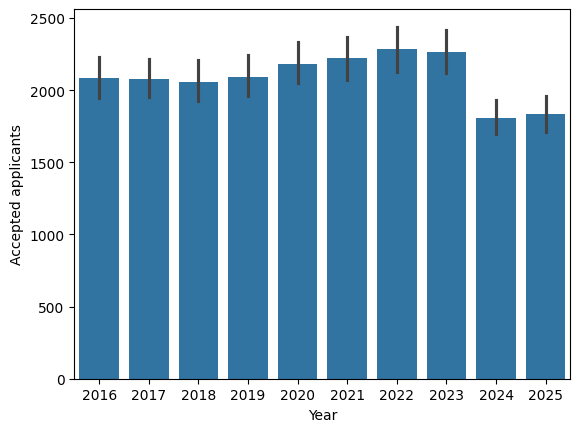

In [9]:
sns.barplot(data=df, x='Year', y='Accepted applicants')

A big dip in applicants between 2023 and 2024 - what could cause this?

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'North West'),
  Text(1, 0, 'Yorkshire and The Humber'),
  Text(2, 0, 'East Midlands'),
  Text(3, 0, 'West Midlands'),
  Text(4, 0, 'East of England'),
  Text(5, 0, 'London'),
  Text(6, 0, 'South East'),
  Text(7, 0, 'Scotland'),
  Text(8, 0, 'North East'),
  Text(9, 0, 'South West'),
  Text(10, 0, 'Wales'),
  Text(11, 0, 'Unknown'),
  Text(12, 0, 'Northern Ireland'),
  Text(13, 0, 'All')])

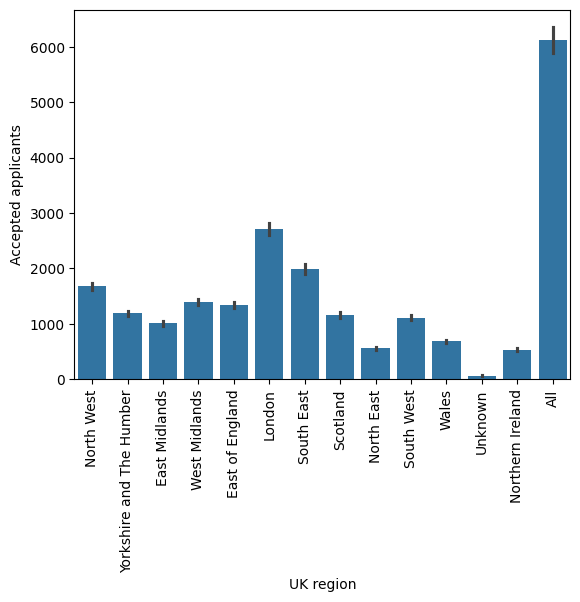

In [13]:
sns.barplot(data=df, x='UK region', y='Accepted applicants')
plt.xticks(rotation=90)

A lot of students in London, South East, North West and South West - would be interesting to see how many universities there are in each area

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, '17 and under'),
  Text(1, 0, '18'),
  Text(2, 0, '19'),
  Text(3, 0, '20'),
  Text(4, 0, '21 - 24'),
  Text(5, 0, '25 - 29'),
  Text(6, 0, '30 - 34'),
  Text(7, 0, '35 and over'),
  Text(8, 0, 'All')])

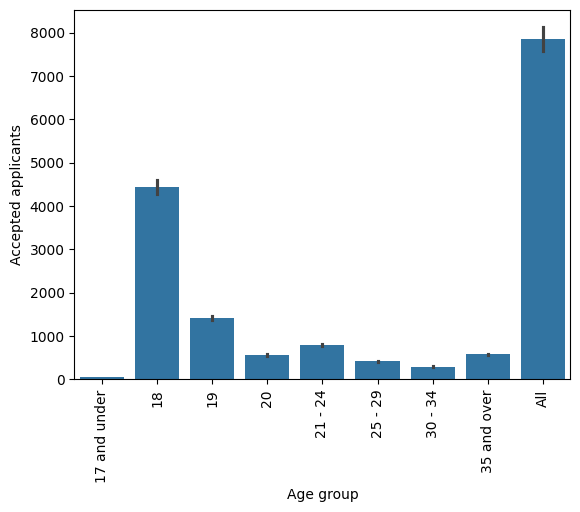

In [14]:
sns.barplot(data=df, x='Age group', y='Accepted applicants')
plt.xticks(rotation=90)

As expected

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Woman'),
  Text(1, 0, 'Man'),
  Text(2, 0, 'I use another term'),
  Text(3, 0, 'I prefer not to say'),
  Text(4, 0, 'All')])

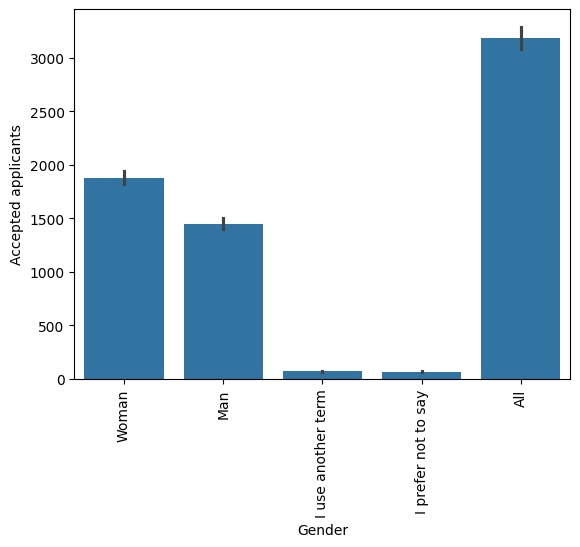

In [15]:
sns.barplot(data=df, x='Gender', y='Accepted applicants')
plt.xticks(rotation=90)

Interesting - had seen some studies around this, but the gap is bigger than expected

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Direct Clearing'),
  Text(1, 0, 'RPA'),
  Text(2, 0, 'Extra'),
  Text(3, 0, 'Main scheme Clearing'),
  Text(4, 0, 'Adjustment'),
  Text(5, 0, 'Other main scheme choice'),
  Text(6, 0, 'Main scheme firm choice'),
  Text(7, 0, 'Main scheme insurance choice'),
  Text(8, 0, 'All')])

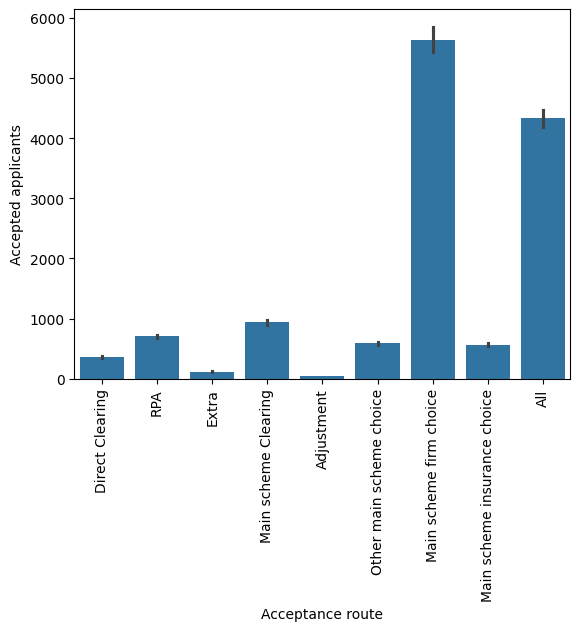

In [16]:
sns.barplot(data=df, x='Acceptance route', y='Accepted applicants')
plt.xticks(rotation=90)

As expected, however worrying that 'All' is lower than 'Main scheme firm choice'. Will be reviewing

Reviewed - filtering issue - not to be concerned about

Now reviewing data for k mode clustering. Need to aggregate, going to do this by aggregating data

In [19]:
df_kmode = df[
    ["UK region",
     "Acceptance route",
     "Age group",
     "Domicile",
     "Gender",
     "Main scheme applicant"
    ]
    ]

In [21]:
from kmodes.kmodes import KModes

km = KModes(
    n_clusters=4,
    init="Cao",
    n_init=5,
    verbose=1
)

clusters = km.fit_predict(df_kmode)
df_kmode["cluster"] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 981391.0


C:\Users\mcmathc\AppData\Local\Temp\ipykernel_10272\211299464.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kmode["cluster"] = clusters


In [22]:
centroids = pd.DataFrame(
    km.cluster_centroids_,
    columns=df_kmode.columns[:-1]  # everything except 'cluster'
)

centroids["cluster"] = centroids.index
centroids

,UK region,Acceptance route,Age group,Domicile,Gender,Main scheme applicant,cluster
0,All,All,All,All,All,All,0
1,London,Main scheme firm choice,18,England,Woman,Main scheme applicant,1
2,South East,RPA,19,England,Man,All,2
3,Scotland,Main scheme Clearing,21 - 24,All,Man,Main scheme applicant,3


Cluster 0 = all applicants <br>
Cluster 1 = 18-year-old women applicants, through main scheme, from London <br>
Cluster 2 = 19-year old male applicants, applying through RPA from the South East <br>
CLuster 3 = 21-24 year-old male applicants, applying through clearning in England

In [23]:
df_with_clusters = df.copy()
df_with_clusters['cluster'] = df_kmode['cluster']

In [24]:
cluster_volume = (
    df_with_clusters
    .groupby('cluster')['Accepted applicants']
    .sum()
    .sort_values(ascending=False)
)
cluster_volume

cluster
0    440428115
1    129963890
2     25206950
3     18749050
Name: Accepted applicants, dtype: int64

In [25]:
cluster_summary = (
    df_with_clusters
    .groupby('cluster')
    .agg(
        accepted_total=('Accepted applicants', 'sum')
    )
    .merge(centroids, on='cluster')
    .sort_values('accepted_total', ascending=False)
)
cluster_summary

,cluster,accepted_total,UK region,Acceptance route,Age group,Domicile,Gender,Main scheme applicant
0,0,440428115,All,All,All,All,All,All
1,1,129963890,London,Main scheme firm choice,18,England,Woman,Main scheme applicant
2,2,25206950,South East,RPA,19,England,Man,All
3,3,18749050,Scotland,Main scheme Clearing,21 - 24,All,Man,Main scheme applicant
